In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm, utils, theory, pickle, os, cluster_utils
from numpy.linalg import inv as inv

%load_ext autoreload
%autoreload 2

plt.rcParams['figure.dpi'] = 100

local_path = '/Users/haozheshan/Dropbox/codes/gp_continual_learning/cluster_results'

trial_inds = np.arange(15)
optimal_lambdas = []
batch_name = 'cifar_test'
argsreader = cluster_utils.ArgsReader()

all_test_loss = []

plt.figure()
colors = plt.cm.coolwarm(np.linspace(0, 1, len(trial_inds)))
for i in range(len(trial_inds)):
    try:
        data = pickle.load(open(f'{local_path}/{batch_name}_{trial_inds[i]}.results', 'rb'))
    except:
        continue
    plt.plot(data['lambda'], data['test loss'][:, :, -1].mean(1), color=colors[i])
    optimal_lambdas.append(data['lambda'][np.argmin(data['test loss'][:, :, -1].mean(1))])
    all_test_loss.append(data['test loss'])
    argsreader.add_args(data['args'])

ind_label, ind_axis = argsreader.get_ind_var()
plt.xscale('log')
plt.xlabel('lambda')
plt.ylabel('normalized MSE')
plt.title('test loss on last task (averaged over random seeds)')
plt.grid()


plt.figure()
for i in range(len(trial_inds)):
    try:
        data = pickle.load(open(f'{local_path}/{batch_name}_{trial_inds[i]}.results', 'rb'))
    except:
        continue
    plt.plot(data['lambda'], data['train loss'][:, :, -1, 0].mean(1), color=colors[i])
    plt.xscale('log')
plt.xlabel('lambda')
plt.ylabel('normalized MSE')
plt.title('train loss on first task (averaged over random seeds)')
plt.grid()

KeyError: 'lambda'

<Figure size 600x400 with 0 Axes>

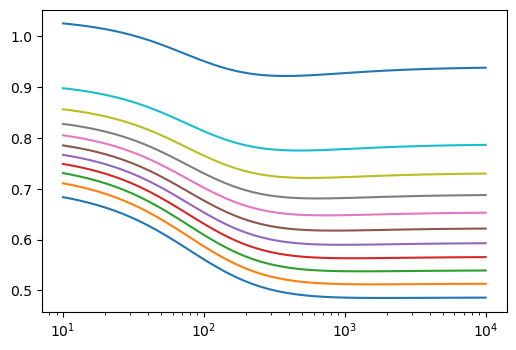

In [43]:
mean_test_loss = np.array(all_test_loss).mean(2)
mean_test_loss_over_tasks = mean_test_loss.mean(2)

plt.figure()
for i in range(11):
    plt.plot(data['lambda'], mean_test_loss_over_tasks[i])

plt.xscale('log')

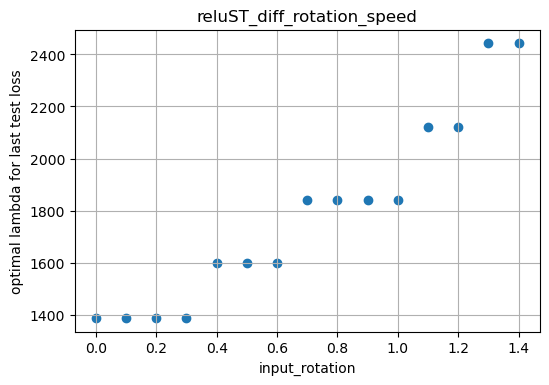

In [57]:
plt.figure()
plt.scatter(ind_axis, optimal_lambdas)
plt.ylabel('optimal lambda for last test loss')
# plt.yscale('log')
plt.xlabel(ind_label)
plt.title(batch_name)
plt.grid()

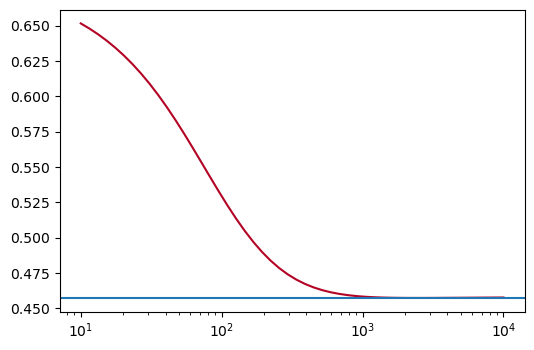

In [60]:
plt.figure()
plt.plot(data['lambda'], data['test loss'][:, :, -1].mean(1), color=colors[i])
plt.xscale('log')
plt.axhline(data['test loss'][:, :, -1].mean(1).min())